# 확률통계 · Topic 0 자율 온보딩

**부산대학교 정보컴퓨터공학부 · 김종덕 (kimjd@pusan.ac.kr)**

---

이 노트북을 끝내면 다음을 할 수 있다.

1. **Colab에서 코드 셀을 실행**하고 결과를 확인할 수 있다.
2. **NumPy 배열**로 여러 개의 수를 한 번에 다루고, 평균·표준편차를 구할 수 있다.
3. **난수를 생성**해서 간단한 시뮬레이션을 돌리고 **그래프로 그릴 수 있다.**

⏱ **예상 소요 시간: 30분** · 성적에 반영되지 않는다. 편하게 해보면 된다.

> 이 과목은 매주 랩(lab)에서 코드를 실행한다.
> 개강 첫 주에 `pip install`이나 문법 오류로 시간을 버리지 않게 하는 것이 이 노트북의 목적이다.
> **Python을 잘 몰라도 괜찮다.** 여기 나오는 것만 알면 Topic 1 랩은 따라올 수 있다.

## Part 0. Colab 사용법 (3분)

- 아래 회색 상자가 **코드 셀(code cell)** 이다.
- 셀을 클릭하고 **`Shift` + `Enter`** 를 누르면 실행된다. (또는 왼쪽 ▶ 버튼)
- **반드시 위에서 아래로 순서대로 실행**한다. 아래 셀이 위 셀의 결과를 쓰기 때문이다.
- 뭔가 꼬였다 싶으면 메뉴의 **런타임 → 런타임 다시 시작** 후 처음부터 다시 실행하면 된다.
- 내 사본으로 저장하려면 **파일 → 드라이브에 사본 저장**.

먼저 아래 셀을 실행해보자.

In [ ]:
print("Hello, 확률통계!")

# Python은 계산기로도 쓸 수 있다
print(2 ** 10)      # 거듭제곱
print(7 / 2)        # 나눗셈 (실수)
print(7 // 2)       # 몫
print(7 % 2)        # 나머지

Hello, 확률통계!
1024
3.5
3
1


## Part 1. Python 최소 문법 (5분)

이 과목에서 실제로 쓰는 문법은 이 정도가 전부다.

In [ ]:
# 1) 변수 - 타입을 안 적는다
n = 10
p = 0.5
name = "확률통계"

# 2) 리스트 - 여러 값을 순서대로 담는 상자
scores = [88, 72, 95, 60, 43]
print(scores[0])      # 첫 번째 (0부터 센다!)
print(scores[-1])     # 마지막
print(len(scores))    # 개수

# 3) 반복문
total = 0
for s in scores:
    total = total + s
print("합계:", total)

# 4) 조건문
if total / len(scores) >= 70:
    print("평균 70점 이상")
else:
    print("평균 70점 미만")

# 5) 함수
def square(x):
    return x * x

print(square(9))

88
43
5
합계: 358
평균 70점 이상
81


### ⚠️ 자주 하는 실수: 들여쓰기

Python은 **들여쓰기(indent)로 코드 블록을 구분**한다. `for`나 `if` 다음 줄은 반드시 들여써야 하고,
같은 블록 안에서는 들여쓰기 칸 수가 같아야 한다. (보통 스페이스 4칸)

`IndentationError`가 나면 십중팔구 이 문제다.

## Part 2. NumPy — 왜 리스트 대신 배열인가 (8분)

확률통계 랩에서는 **수천, 수백만 개의 수를 한꺼번에** 다룬다.
그때 Python 리스트는 느리고 불편하다. **NumPy 배열(array)** 을 쓴다.

차이를 먼저 보자.

In [ ]:
import numpy as np

scores_list = [88, 72, 95, 60, 43]
scores_arr = np.array(scores_list)   # 리스트 -> 배열

print("리스트 * 2 :", scores_list * 2)   # 통째로 두 번 반복된다!
print("배열   * 2 :", scores_arr * 2)    # 각 원소가 2배 - 우리가 원하는 것

리스트 * 2 : [88, 72, 95, 60, 43, 88, 72, 95, 60, 43]
배열   * 2 : [176 144 190 120  86]


배열은 **원소 하나하나에 연산이 적용된다.** 이것이 이 과목에서 NumPy를 쓰는 이유다.
`for` 문 없이 한 줄로 계산이 끝난다.

In [ ]:
# 배열 만드는 방법들
a = np.arange(10)             # 0, 1, 2, ..., 9
b = np.linspace(0, 1, 5)      # 0부터 1까지 균등하게 5개
c = np.zeros(4)               # 0으로 채운 배열
d = np.ones(4)                # 1로 채운 배열

print("a =", a)
print("b =", b)
print("c =", c)
print("d =", d)
print("a의 크기(shape):", a.shape)   # 배열의 모양 - 자주 확인하게 된다

a = [0 1 2 3 4 5 6 7 8 9]
b = [0.   0.25 0.5  0.75 1.  ]
c = [0. 0. 0. 0.]
d = [1. 1. 1. 1.]
a의 크기(shape): (10,)


In [ ]:
# 인덱싱과 슬라이싱
a = np.arange(10)

print(a[0])       # 첫 번째
print(a[-1])      # 마지막
print(a[2:5])     # 2번부터 4번까지 (5번은 포함 안 됨)
print(a[:3])      # 처음부터 2번까지
print(a[::2])     # 2칸씩 건너뛰며

# 불리언 마스크(boolean mask) - 조건에 맞는 것만 골라내기
print(a > 5)      # 각 원소가 조건을 만족하는지 True/False 배열
print(a[a > 5])   # True인 것만 골라낸 배열

0
9
[2 3 4]
[0 1 2]
[0 2 4 6 8]
[False False False False False False  True  True  True  True]
[6 7 8 9]


> **불리언 마스크는 이 과목 내내 쓴다.** "시뮬레이션 결과 중 조건을 만족한 것이 몇 개인가"를
> 세는 것이 곧 확률 추정이기 때문이다. `(조건).sum()` 한 줄이면 개수가 나온다.

### ✏️ 실습 1

`scores` 배열의 **평균**과 **표준편차**를 구해보자.
`np.mean(배열)` / `np.std(배열)` 또는 `배열.mean()` / `배열.std()` 를 쓰면 된다.

In [ ]:
scores = np.array([88, 72, 95, 60, 43, 77, 81, 55, 90, 68])

mean_score = np.mean(scores)   # scores의 평균
std_score = np.std(scores)     # scores의 표준편차

print("평균:", mean_score)
print("표준편차:", std_score)

평균: 72.9
표준편차: 15.801582199260933


### ✏️ 실습 2

`scores`에서 **70점 이상인 학생 수**를 세어보자.

힌트: `scores >= 70` 은 True/False 배열이다. Python에서 `True`는 1, `False`는 0으로 계산되므로
**`.sum()` 을 붙이면 True의 개수**가 나온다.

In [ ]:
n_pass = (scores >= 70).sum()   # TODO: 70점 이상인 학생 수를 세세요

print("70점 이상:", n_pass, "명")

70점 이상: 6 명


## Part 3. 난수 — 시뮬레이션의 엔진 (6분)

이 과목의 철학은 **"먼저 시뮬레이션으로 보고, 그 다음 수식으로 설명한다"** 이다.
그 시뮬레이션의 재료가 **난수(random number)** 다.

이 과목에서는 난수 생성기를 **항상 이렇게** 만든다.

```python
rng = np.random.default_rng(20260302)
```

괄호 안의 숫자를 **시드(seed)** 라고 한다. 시드가 같으면 **몇 번을 돌려도 똑같은 난수**가 나온다.
"랜덤인데 똑같다"는 게 이상하게 들리겠지만, 이건 매우 중요하다.
**과제 결과를 채점자가 그대로 재현할 수 있어야 하기 때문**이다.

In [ ]:
rng = np.random.default_rng(20260302)   # 이 과목 공통 시드

print(rng.integers(1, 7, size=10))      # 1 이상 7 미만의 정수 10개 = 주사위 10번
print(rng.random(5))                    # 0과 1 사이의 실수 5개
print(rng.choice(["H", "T"], size=10))  # 주어진 것 중에서 무작위로 고르기 = 동전 10번

# 시드를 다시 같게 주면 -> 위와 똑같은 결과가 나온다
rng2 = np.random.default_rng(20260302)
print(rng2.integers(1, 7, size=10))

[2 3 3 4 1 2 4 4 1 2]
[0.84647809 0.1743864  0.77139964 0.86928752 0.77457049]
['T' 'H' 'H' 'T' 'H' 'H' 'H' 'T' 'H' 'T']
[2 3 3 4 1 2 4 4 1 2]


> ⚠️ 인터넷 예제에는 `np.random.seed(0)` / `np.random.randint(...)` 형태가 많이 나온다.
> 그건 **옛날 방식**이다. 이 과목에서는 `default_rng`로 통일한다.

### ✏️ 실습 3

주사위를 **1,000번** 던져서 각 눈이 몇 번 나왔는지 세어보자.

힌트: `np.bincount(배열)` 은 0, 1, 2, ... 가 각각 몇 번 나왔는지 세어준다.
주사위 눈은 1부터 시작하므로 `[1:]` 로 0번 자리를 잘라내면 된다.

In [ ]:
rng = np.random.default_rng(20260302)

rolls = rng.integers(1, 7, size=1000)    # TODO: 1~6 사이 정수를 1000개 생성하세요
counts = np.bincount(rolls)[1:]
# TODO: 각 눈이 몇 번 나왔는지 세세요 (np.bincount 사용, [1:]로 자르기)

print("각 눈의 횟수:", counts)
print("이론값:", 1 / 6)

각 눈의 횟수: [185 161 179 145 166 164]
이론값: 0.16666666666666666


## Part 4. matplotlib — 그림으로 보기 (5분)

숫자만 보면 감이 안 온다. 이 과목에서는 **거의 모든 결과를 그림으로 확인**한다.

> 📌 **그래프의 축 라벨·제목은 영어로 쓴다.**
> Colab 서버에는 한글 폰트가 없어서 한글을 쓰면 네모(□□□)로 깨진다.

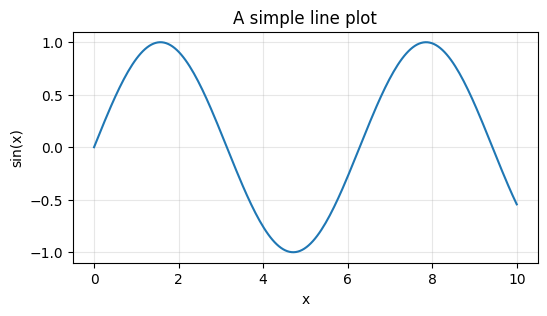

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)
y = np.sin(x)

plt.figure(figsize=(6, 3))
plt.plot(x, y)
plt.xlabel("x")               # 축 이름 - 항상 붙이는 습관을 들이자
plt.ylabel("sin(x)")
plt.title("A simple line plot")
plt.grid(alpha=0.3)
plt.show()

### ✏️ 실습 4

실습 3에서 구한 주사위 빈도 `counts` 를 **막대그래프**로 그려보자.

힌트: `plt.bar(x위치, 높이)` — x위치는 `np.arange(1, 7)` 로 만들면 된다.

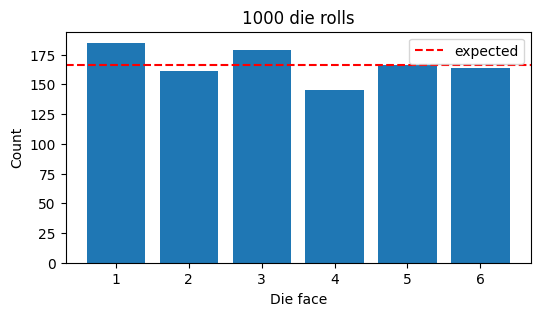

In [ ]:
plt.figure(figsize=(6, 3))
# TODO: 1~6 눈의 빈도를 막대그래프로 그리세요
plt.bar(np.arange(1, 7), counts)

plt.axhline(1000 / 6, color="red", linestyle="--", label="expected")
plt.xlabel("Die face")
plt.ylabel("Count")
plt.title("1000 die rolls")
plt.legend()
plt.show()

## Part 5. 미니 실습 — 동전을 몇 번 던져야 할까 (3분)

마지막이다. **공정한 동전을 계속 던지면서, 앞면이 나온 비율이 어떻게 변하는지** 그려보자.

- 앞면 = 1, 뒷면 = 0 으로 두면
- **처음 n번까지의 앞면 비율 = (앞의 n개 합) / n**
- `np.cumsum(배열)` 이 "앞에서부터 누적 합"을 한 번에 만들어 준다.

### ✏️ 실습 5

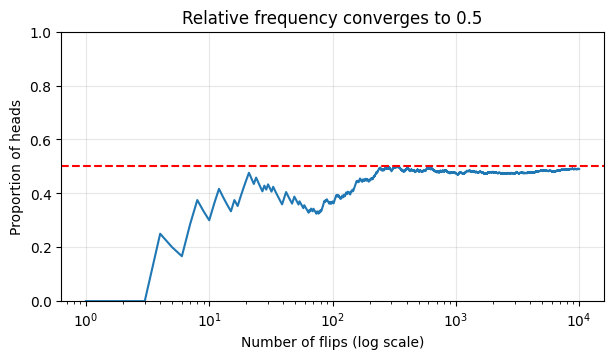

In [ ]:
rng = np.random.default_rng(20260302)

n_flips = 10000
flips = rng.integers(0, 2, size=n_flips)   # 0 또는 1
n = np.arange(1, n_flips + 1)    # 1, 2, 3, ..., 10000

running_ratio = np.cumsum(flips) / n   # TODO: 누적 앞면 비율로 바꾸세요 (np.cumsum 사용)
# 지금 실행하면 0인 직선만 그려진다. 위 줄을 채우면 곡선이 나타난다.

plt.figure(figsize=(7, 3.5))
plt.plot(n, running_ratio)
plt.axhline(0.5, color="red", linestyle="--")
plt.xscale("log")
plt.ylim(0, 1)
plt.xlabel("Number of flips (log scale)")
plt.ylabel("Proportion of heads")
plt.title("Relative frequency converges to 0.5")
plt.grid(alpha=0.3)
plt.show()

### 🤔 생각해볼 질문

그래프를 보면 던질수록 0.5에 가까워지지만, **정확히 0.5가 되지는 않는다.**

> **몇 번을 던져야 "이 동전은 공정하다"고 믿을 수 있을까?**

이 질문에는 지금 답하지 않는다. Topic 1에 다시 만나고,
**Topic 10(대수의 법칙 · 중심극한정리)에서 정확한 답**을 하게 된다.
한 학기 동안 이 질문을 들고 다니면 된다.

## 마무리 — 자가 점검

아래 항목을 스스로 체크해보자. (셀을 더블클릭하면 편집할 수 있다. `[ ]` 를 `[x]` 로 바꾸면 된다.)

- [ ] 코드 셀을 실행할 수 있다 (`Shift` + `Enter`)
- [ ] `np.array` 로 배열을 만들고 평균·표준편차를 구할 수 있다
- [ ] 불리언 마스크로 조건에 맞는 원소의 개수를 셀 수 있다
- [ ] `np.random.default_rng(seed)` 로 난수를 만들 수 있다
- [ ] `plt.plot` / `plt.bar` 로 그래프를 그리고 축 이름을 붙일 수 있다

**오늘 해본 것 중 가장 인상적이었던 것을 한 문장으로 써보자.**

> (여기에 작성)

---

막히는 부분이 있으면 Topic 1 수업 전에 이메일(kimjd@pusan.ac.kr) 또는 PLATO 쪽지로 알려주면 된다.
**Part 1~2에서 막혔다면 그건 정상이다.** Topic 1 랩은 코드를 읽고 숫자만 바꾸는 수준에서 시작한다.

## 부록 — 자주 만나는 에러 5가지

| 에러 메시지 | 원인 | 해결 |
|---|---|---|
| `NameError: name 'np' is not defined` | `import numpy as np` 셀을 실행 안 함 | 위 셀부터 순서대로 실행 |
| `IndentationError` | 들여쓰기가 어긋남 | `for` / `if` 다음 줄은 스페이스 4칸 |
| `IndexError: index out of range` | 없는 위치를 꺼내려 함 | 인덱스는 **0부터**, 마지막은 `len-1` |
| `TypeError: unsupported operand ...` | 리스트와 숫자를 연산 | `np.array(...)` 로 배열로 바꾸기 |
| 그래프에 글자가 □□□ | Colab에 한글 폰트 없음 | 축 라벨을 **영어로** |